# Measuring emission lines step by step

The BPT notebook lets **FastSpecFit** do the hard work. Here we redo the measurement of one DESI spectrum
**by hand**, one step per cell, with nothing but numpy, scipy and the same stellar templates:

1. load the spectrum, 2. correct for Milky-Way dust, 3. shift to the rest frame, 4. mask the emission
lines, 5. fit the stellar continuum (templates × velocity dispersion × dust, non-negative least squares),
6. add a smooth correction for what the templates cannot reproduce, 7. subtract the continuum,
8. fit Gaussians to Hβ, [O III], Hα + [N II], [S II], 9. compare with FastSpecFit, 10. BPT.

Each step has a figure. The galaxy is IC 3147B by default (change `SYSTEM`).

In [1]:
import os, io
from pathlib import Path
import numpy as np, pandas as pd, fitsio, requests
import matplotlib.pyplot as plt
from scipy.optimize import nnls, curve_fit
from scipy.ndimage import gaussian_filter1d, median_filter

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DESI = Path(os.environ.get("INTERBARS_DESI", ROOT / "output" / "desi_redux"))
C_KMS = 299792.458
plt.rcParams.update({"figure.dpi": 110})

SYSTEM = "IC3147B"
m = pd.read_csv(ROOT / "dataset/catalogs/specz_matches.csv", dtype={"obj_id": str})
t = m[(m.survey == "DESI DR1") & (m.system == SYSTEM) & (m.role == "main") & (m.sep_arcsec <= 5) & m.usable]
t = t[t.extra.str.contains("primary=t")].iloc[0]
survey, program, hp = (t.extra.split(";")[0].split("=")[1], t.extra.split(";")[1].split("=")[1], int(t.extra.split(";")[2].split("=")[1]))
d = DESI / "iron" / "healpix" / survey / program / str(hp // 100) / str(hp)
coadd = d / f"coadd-{survey}-{program}-{hp}.fits"
TARGETID, z = int(t.obj_id), float(t.z)
print(f"{SYSTEM}: targetid {TARGETID}  z = {z:.5f}  {coadd.name}")

IC3147B: targetid 39628075859711056  z = 0.02563  coadd-main-bright-27769.fits


## Step 1 — the observed spectrum

DESI has three spectrographs (B, R, Z). We read the row of our target from each and join them into one
array. `ivar` is the inverse variance: pixels with `ivar = 0` are bad. The overlaps between arms are
kept (they are co-added by DESI already at the wavelength level, so we simply concatenate and sort).

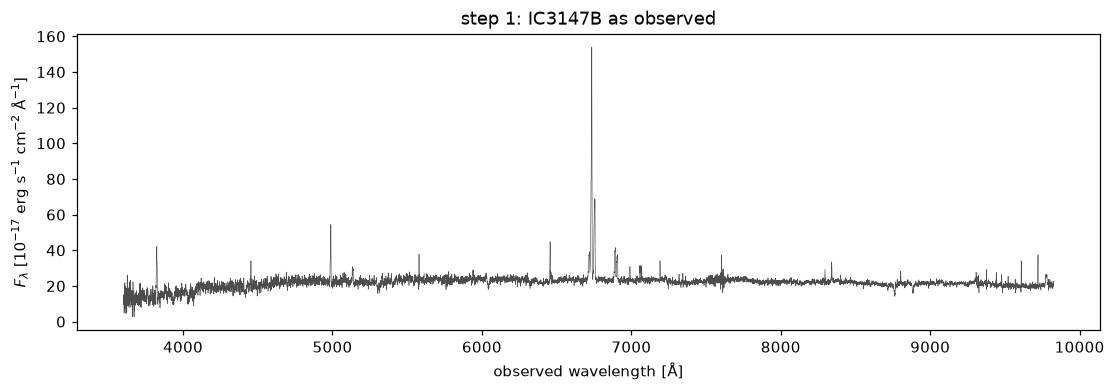

In [2]:
fm = fitsio.read(coadd, "FIBERMAP", columns=["TARGETID", "TARGET_RA", "TARGET_DEC"])
i = int(np.where(fm["TARGETID"] == TARGETID)[0][0])
with fitsio.FITS(coadd) as F:
    parts = [(F[f"{b}_WAVELENGTH"].read(), F[f"{b}_FLUX"][i:i + 1, :][0], F[f"{b}_IVAR"][i:i + 1, :][0]) for b in "BRZ"]
wobs = np.concatenate([p[0] for p in parts]); fobs = np.concatenate([p[1] for p in parts]); ivar = np.concatenate([p[2] for p in parts])
o = np.argsort(wobs); wobs, fobs, ivar = wobs[o], fobs[o], ivar[o]
good = ivar > 0
# instrumental resolution, approximated per arm (sigma in km/s from R = lambda/dlambda_FWHM)
def sigma_inst_kms(wave_obs):
    R = np.where(wave_obs < 5800, 2500., np.where(wave_obs < 7600, 3600., 4500.))
    return C_KMS / (R * 2.3548)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(wobs, np.where(good, fobs, np.nan), lw=0.4, color="0.3")
ax.set(xlabel="observed wavelength [Å]", ylabel=r"$F_\lambda$ [$10^{-17}$ erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]", title=f"step 1: {SYSTEM} as observed"); plt.show()

## Step 2 — Milky-Way extinction

Dust in our own Galaxy reddens every extragalactic spectrum. The colour excess $E(B-V)$ at the target's
position comes from the Schlegel, Finkbeiner & Davis (1998) map (FastSpecFit stored it in its output; the
raw map is in `$DUST_DIR`). We apply the Cardelli, Clayton & Mathis (1989) law with $R_V = 3.1$:
$F_{\rm corr} = F \times 10^{0.4\,A_\lambda}$.

E(B-V)_MW = 0.0339  ->  A_V = 0.105 mag; correction factor 1.041 (red end) to 1.164 (blue end)


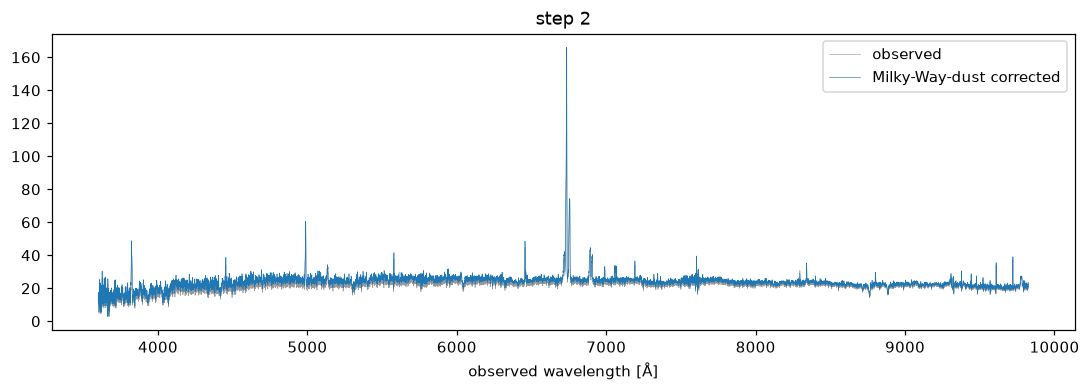

In [3]:
def ccm89(wave_A, ebv, rv=3.1):
    x = 1e4 / wave_A; a = np.zeros_like(x); b = np.zeros_like(x)
    ir = x < 1.1; a[ir] = 0.574 * x[ir] ** 1.61; b[ir] = -0.527 * x[ir] ** 1.61
    op = ~ir; y = x[op] - 1.82
    a[op] = 1 + 0.17699 * y - 0.50447 * y**2 - 0.02427 * y**3 + 0.72085 * y**4 + 0.01979 * y**5 - 0.77530 * y**6 + 0.32999 * y**7
    b[op] = 1.41338 * y + 2.28305 * y**2 + 1.07233 * y**3 - 5.38434 * y**4 - 0.62251 * y**5 + 5.30260 * y**6 - 2.09002 * y**7
    return ebv * rv * (a + b / rv)          # A_lambda [mag]

meta = fitsio.read(ROOT / "output/fastspecfit" / f"fastspec-{SYSTEM}.fits", "METADATA")[0]
ebv = float(meta["EBV"])
A_mw = ccm89(wobs, ebv)
fmw = fobs * 10 ** (0.4 * A_mw); ivar_mw = ivar / 10 ** (0.8 * A_mw)
print(f"E(B-V)_MW = {ebv:.4f}  ->  A_V = {ebv * 3.1:.3f} mag; correction factor {10 ** (0.4 * A_mw.min()):.3f} (red end) to {10 ** (0.4 * A_mw.max()):.3f} (blue end)")
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(wobs, np.where(good, fobs, np.nan), lw=0.4, color="0.6", label="observed")
ax.plot(wobs, np.where(good, fmw, np.nan), lw=0.4, color="tab:blue", label="Milky-Way-dust corrected")
ax.legend(); ax.set(xlabel="observed wavelength [Å]", title="step 2"); plt.show()

## Step 3 — rest frame

Divide the wavelengths by $(1+z)$ (and multiply $F_\lambda$ by $(1+z)$ to conserve the integrated flux).
Line *ratios* do not depend on this, but the templates are in the rest frame, so we must be too.

air -> vacuum: Halpha 6562.80 -> 6564.61 A (= 83 km/s, the size of the mistake if forgotten)


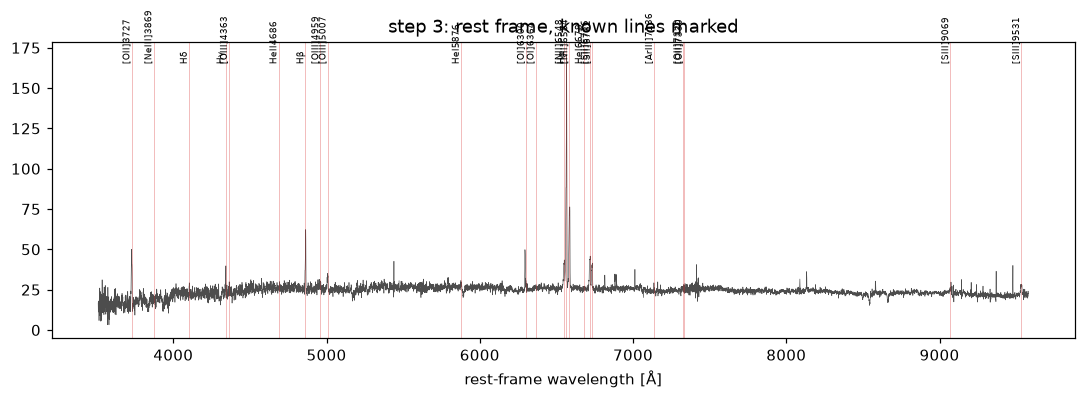

In [4]:
wr = wobs / (1 + z); fr = fmw * (1 + z); ivr = ivar_mw / (1 + z) ** 2
def air_to_vac(w):
    # textbook line wavelengths are quoted in AIR; DESI (and SDSS) wavelengths are in VACUUM (Morton 2000)
    s2 = (1e4 / w) ** 2
    return w * (1 + 8.336624e-5 + 2.408927e-2 / (130 - s2) + 1.599740e-4 / (38.9 - s2))
LINES_AIR = {"[OII]3727": 3727.4, "[NeIII]3869": 3869.9, "Hδ": 4101.7, "Hγ": 4340.5, "[OIII]4363": 4363.2, "HeII4686": 4685.7,
         "Hβ": 4861.3, "[OIII]4959": 4958.9, "[OIII]5007": 5006.8, "HeI5876": 5875.6, "[OI]6300": 6300.3, "[OI]6364": 6363.8,
         "[NII]6548": 6548.0, "Hα": 6562.8, "[NII]6584": 6583.5, "HeI6678": 6678.2, "[SII]6716": 6716.4, "[SII]6731": 6730.8,
         "[ArIII]7136": 7135.8, "[OII]7320": 7320.9, "[OII]7330": 7330.7, "[SIII]9069": 9068.6, "[SIII]9531": 9530.6}
LINES = {n: float(air_to_vac(l)) for n, l in LINES_AIR.items()}
print("air -> vacuum: Halpha %.2f -> %.2f A (= %.0f km/s, the size of the mistake if forgotten)" % (LINES_AIR["Hα"], LINES["Hα"], C_KMS * (LINES["Hα"] / LINES_AIR["Hα"] - 1)))
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(wr, np.where(good, fr, np.nan), lw=0.4, color="0.3")
for n, l in LINES.items():
    ax.axvline(l, color="tab:red", lw=0.4, alpha=0.5); ax.text(l, ax.get_ylim()[1] * 0.93, n, rotation=90, fontsize=6, ha="right")
ax.set(xlabel="rest-frame wavelength [Å]", title="step 3: rest frame, known lines marked"); plt.show()

## Step 4 — mask the emission lines (and the sky)

The continuum fit must not see the emission lines, otherwise the templates try to reproduce them.
Mask ±600 km/s around every line (wider for the strong ones), plus the bright sky-line residuals at
5577 Å and the telluric A band, and the pixels with `ivar = 0`.

7041 of 7958 good pixels used for the continuum (11.5% masked)


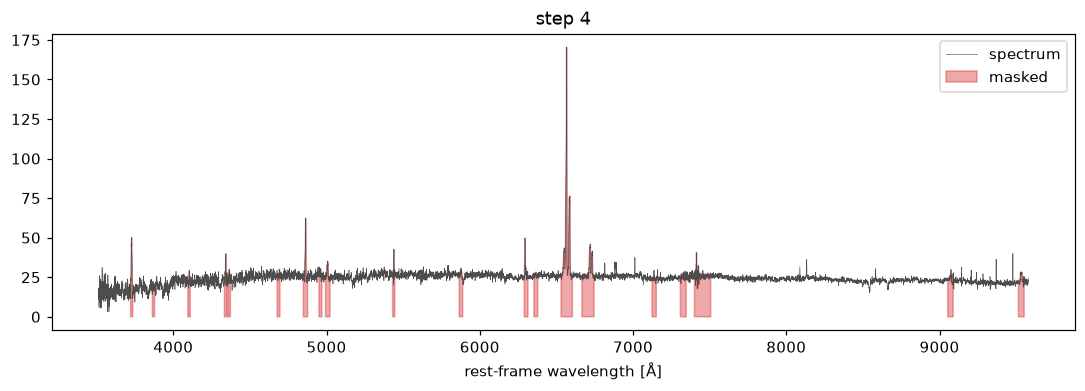

In [5]:
mask = good.copy()                              # True = use in the continuum fit
for n, l in LINES.items():
    half = 900 if n in ("Hα", "[NII]6584", "[NII]6548", "Hβ", "[OIII]5007") else 600
    mask &= np.abs(C_KMS * (wr - l) / l) > half
for lo, hi in [(5570, 5585), (7590, 7700), (6860, 6890)]:        # sky / telluric, observed frame
    mask &= ~((wobs > lo) & (wobs < hi))
print(f"{mask.sum()} of {good.sum()} good pixels used for the continuum ({1 - mask.sum() / good.sum():.1%} masked)")
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(wr, np.where(good, fr, np.nan), lw=0.4, color="0.3", label="spectrum")
ax.fill_between(wr, 0, np.where(~mask & good, fr, np.nan), color="tab:red", alpha=0.4, label="masked")
ax.legend(); ax.set(xlabel="rest-frame wavelength [Å]", title="step 4"); plt.show()

## Step 5 — the stellar continuum

The stellar light is modelled as a **non-negative sum of simple stellar populations** (SSPs: single
age, single metallicity, from the FastSpecFit template file, which is built on the C3K stellar
library with a Chabrier IMF). Three ingredients:

* the templates, resampled onto our wavelength grid;
* a **velocity dispersion** $\sigma_\star$: the templates are broadened with a Gaussian in velocity
  (log-wavelength) space, because the stars in the galaxy move;
* **dust attenuation**: every template is multiplied by $10^{-0.4\,A_V\,k(\lambda)/k_V}$ (Calzetti 2000
  curve), same $A_V$ for all.

For a given $(\sigma_\star, A_V)$ the best weights are a **non-negative least-squares** problem
(`scipy.optimize.nnls`) — non-negative because you cannot have a negative number of stars. We scan a grid
in $(\sigma_\star, A_V)$ and keep the minimum $\chi^2$. FastSpecFit does exactly this, with a finer scan
and the broadband photometry as extra data points.

5 templates; columns: ['age', 'zzsun', 'mstar', 'sfr', 'dt']
                min           max
age    1.500272e+07  1.267250e+10
zzsun  0.000000e+00  0.000000e+00
mstar  5.702459e-01  8.957314e-01
sfr    0.000000e+00  3.332718e-08
dt     3.000544e+07  1.056588e+10
best: sigma* = 60 km/s, A_V = 0.6 mag, chi2/N = 1.24   (FastSpecFit: sigma* = 162 km/s, tau_V = 0.63)


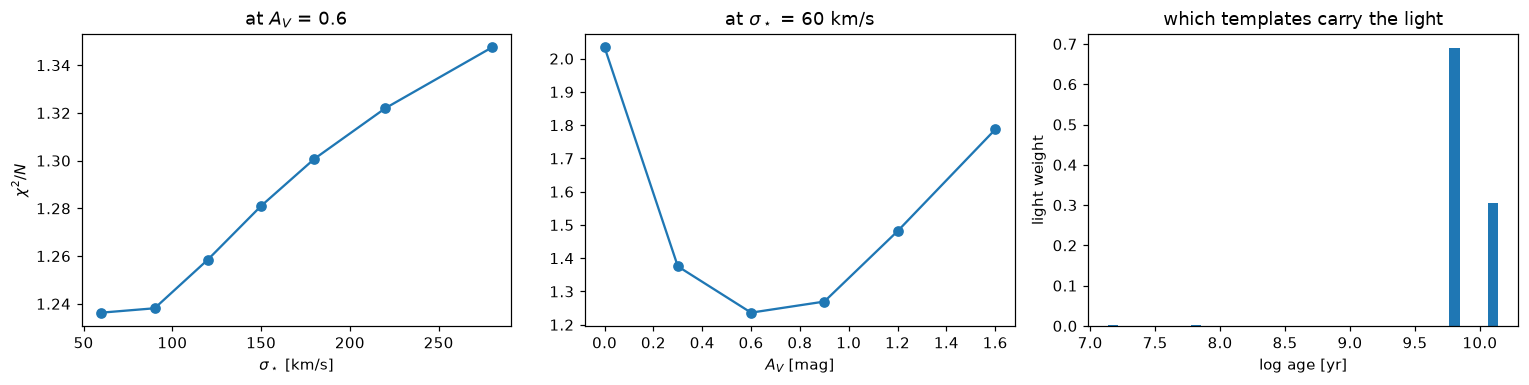

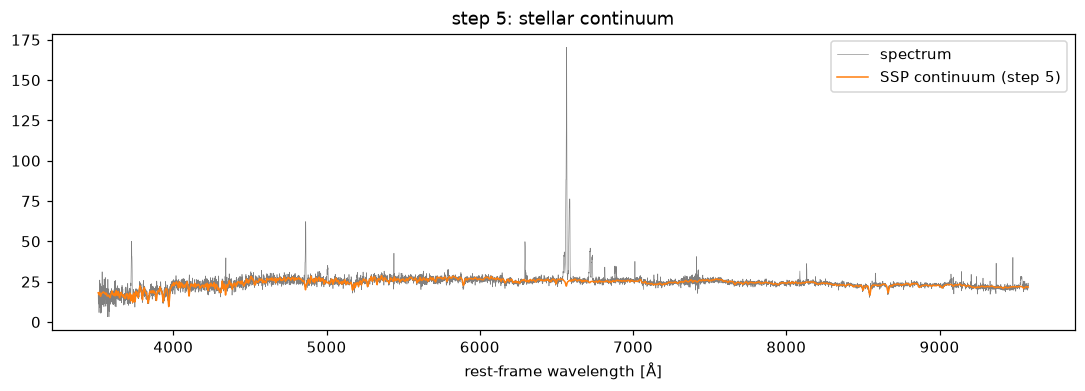

In [6]:
T = fitsio.FITS(DESI / "ftemplates" / "2.2.0" / "ftemplates-chabrier-2.2.0.fits")
twave = T["WAVE"].read(); tflux = (T["FLUX"].read() - T["LINEFLUX"].read()).T     # (ntemplates, npix), nebular lines removed
tinfo = pd.DataFrame(T["METADATA"].read().byteswap().view(T["METADATA"].read().dtype.newbyteorder()))
PIXKMS, SIGMA_C3K = 25.0, C_KMS / (3000 * 2.3548)     # template pixel [km/s] and intrinsic resolution
sel = (twave > 3300) & (twave < 9600); twave, tflux = twave[sel], tflux[:, sel]
print(f"{tflux.shape[0]} templates; columns: {list(tinfo.columns)}")
print(tinfo.describe().loc[["min", "max"]].T.head(6))

def calzetti_k(wave_A):
    w = wave_A / 1e4; k = np.where(w < 0.63, 2.659 * (-2.156 + 1.509 / w - 0.198 / w**2 + 0.011 / w**3) + 4.05,
                                   2.659 * (-1.857 + 1.040 / w) + 4.05)
    return np.clip(k, 0, None)
kV = calzetti_k(np.array([5500.]))[0]

SIGMA_INST_B = float(sigma_inst_kms(np.array([5000. * (1 + z)]))[0])   # the data are broadened by the instrument too
def build_templates(vdisp, av):
    sig_pix = np.sqrt(max(vdisp**2 + SIGMA_INST_B**2 - SIGMA_C3K**2, 1.0)) / PIXKMS
    broad = gaussian_filter1d(tflux, sig_pix, axis=1)
    att = 10 ** (-0.4 * av * calzetti_k(twave) / kV)
    return np.array([np.interp(wr, twave, f * att) for f in broad])      # (ntemplates, ndata)

def fit_continuum(vdisp, av):
    A = build_templates(vdisp, av)
    w = np.sqrt(ivr[mask])
    coef, rnorm = nnls((A[:, mask] * w).T, fr[mask] * w, maxiter=5000)
    model = coef @ A
    fitrange = mask & (wr > 3800) & (wr < 5600)                     # where the stellar absorption lines are
    chi2 = np.sum(((fr - model) ** 2 * ivr)[fitrange]) / fitrange.sum()
    return coef, model, chi2

vgrid, agrid = np.array([60, 90, 120, 150, 180, 220, 280]), np.array([0.0, 0.3, 0.6, 0.9, 1.2, 1.6])
chi2 = np.array([[fit_continuum(v, a)[2] for a in agrid] for v in vgrid])          # already per pixel
iv, ia = np.unravel_index(np.argmin(chi2), chi2.shape)
vbest, abest = vgrid[iv], agrid[ia]
coef, cont_ssp, chi2best = fit_continuum(vbest, abest)
print(f"best: sigma* = {vbest} km/s, A_V = {abest} mag, chi2/N = {chi2best:.2f}   (FastSpecFit: sigma* = 162 km/s, tau_V = 0.63)")

fig, axs = plt.subplots(1, 3, figsize=(14, 3.6))
axs[0].plot(vgrid, chi2[:, ia], "o-"); axs[0].set(xlabel=r"$\sigma_\star$ [km/s]", ylabel=r"$\chi^2/N$", title=f"at $A_V$ = {abest}")
axs[1].plot(agrid, chi2[iv, :], "o-"); axs[1].set(xlabel="$A_V$ [mag]", title=rf"at $\sigma_\star$ = {vbest} km/s")
age_col = [c for c in tinfo.columns if c.lower().startswith("age")][0]
lw = coef / coef.sum()
axs[2].bar(np.log10(tinfo[age_col][coef > 0] * (1e9 if tinfo[age_col].max() < 100 else 1)), lw[coef > 0], width=0.08)
axs[2].set(xlabel="log age [yr]", ylabel="light weight", title="which templates carry the light")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(wr, np.where(good, fr, np.nan), lw=0.4, color="0.5", label="spectrum")
ax.plot(wr, cont_ssp, color="tab:orange", lw=1, label="SSP continuum (step 5)")
ax.legend(); ax.set(xlabel="rest-frame wavelength [Å]", title="step 5: stellar continuum"); plt.show()

## Step 6 — smooth correction

The templates never reproduce the data perfectly (flux-calibration ripples, the aperture, template
limitations). FastSpecFit adds a **smooth continuum correction**: the residual (data − SSP model), with
the lines masked, is smoothed on a scale of ~100 Å and added back. Same here with a running median.
The important property: it is far too smooth to absorb an emission line.

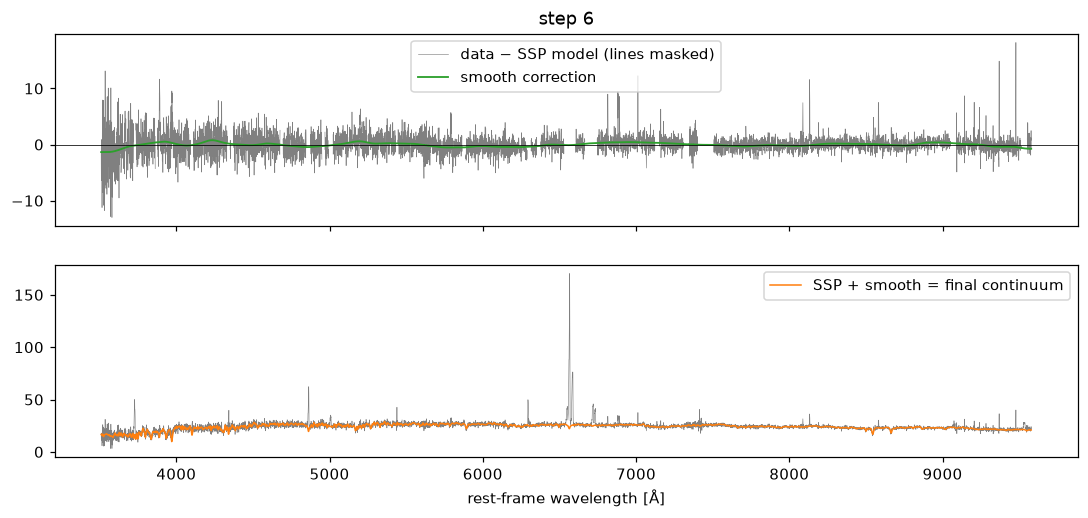

In [7]:
resid = np.where(mask, fr - cont_ssp, np.nan)
# running median on the masked residual, then interpolate across the masked gaps and smooth
x = np.arange(len(wr)); ok = np.isfinite(resid)
smooth = np.interp(x, x[ok], median_filter(resid[ok], size=151, mode="nearest"))
smooth = gaussian_filter1d(smooth, 40)
cont = cont_ssp + smooth
fig, axs = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axs[0].plot(wr, resid, lw=0.4, color="0.5", label="data − SSP model (lines masked)"); axs[0].plot(wr, smooth, color="tab:green", lw=1.2, label="smooth correction"); axs[0].axhline(0, color="k", lw=0.5); axs[0].legend()
axs[1].plot(wr, np.where(good, fr, np.nan), lw=0.4, color="0.5"); axs[1].plot(wr, cont, color="tab:orange", lw=1, label="SSP + smooth = final continuum"); axs[1].legend()
axs[1].set(xlabel="rest-frame wavelength [Å]"); axs[0].set_title("step 6"); plt.show()

## Step 7 — subtract, and see why it matters

Hβ and Hα sit in **stellar Balmer absorption** lines. A naive continuum (straight line under the emission
line) is too high inside the absorption trough and underestimates the emission flux — especially Hβ,
which is weak. Compare the two continua below.

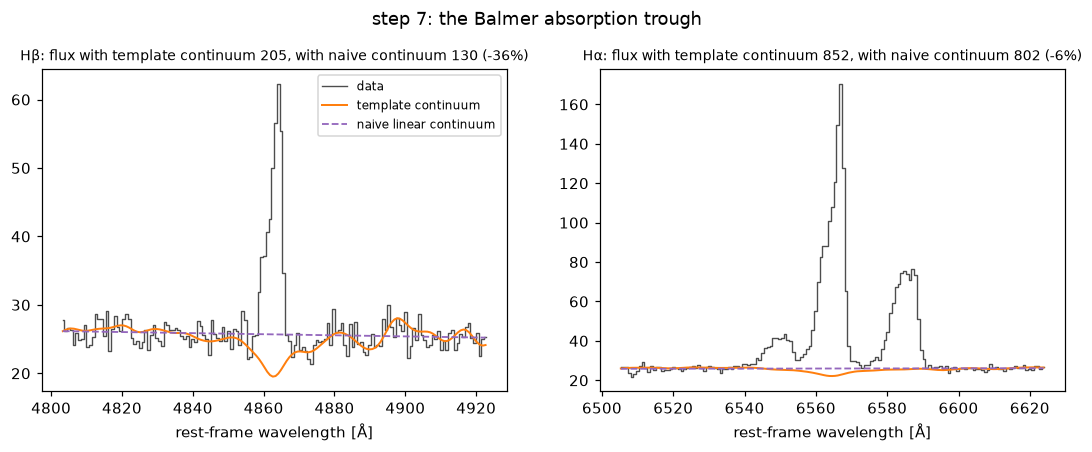

In [8]:
fline = fr - cont
fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, (l0, name, w) in zip(axs, [(LINES["Hβ"], "Hβ", 60), (LINES["Hα"], "Hα", 60)]):
    s = (wr > l0 - w) & (wr < l0 + w)
    ax.plot(wr[s], fr[s], color="0.3", lw=0.9, drawstyle="steps-mid", label="data")
    ax.plot(wr[s], cont[s], color="tab:orange", lw=1.3, label="template continuum")
    side = s & (np.abs(wr - l0) > 25) & mask
    p = np.polyfit(wr[side], fr[side], 1); ax.plot(wr[s], np.polyval(p, wr[s]), "--", color="tab:purple", lw=1.2, label="naive linear continuum")
    core = s & (np.abs(wr - l0) < 12)
    f_t = np.trapezoid((fr - cont)[core], wr[core]); f_n = np.trapezoid((fr - np.polyval(p, wr))[core], wr[core])
    ax.set_title(f"{name}: flux with template continuum {f_t:.0f}, with naive continuum {f_n:.0f} ({f_n / f_t - 1:+.0%})", fontsize=9)
    ax.set_xlabel("rest-frame wavelength [Å]")
axs[0].legend(fontsize=8); plt.suptitle("step 7: the Balmer absorption trough", y=1.02); plt.show()

## Step 8 — Gaussian line fits, all lines together

Each line is a Gaussian in velocity: centre $\lambda_0(1+v/c)$, width $\sigma_{\rm obs}^2 = \sigma_{\rm gas}^2 + \sigma_{\rm inst}^2$
(the instrument broadens the lines; we remove that in quadrature). Physics fixes some parameters, and
we fit **all four complexes at once** so that they share them (this is what FastSpecFit calls the
narrow-line kinematic groups):

* one velocity $v$ for every line;
* one width for the **Balmer** lines (Hβ, Hα) and one for the **forbidden** lines ([O III], [N II], [S II]) —
  recombination and collisionally excited lines need not come from the same gas;
* doublet ratios fixed by atomic physics: [O III] 5007/4959 = 2.98, [N II] 6584/6548 = 2.96;
  [S II] 6716/6731 stays free (it measures the electron density).

Flux $= A\,\sqrt{2\pi}\,\sigma_\lambda$; uncertainties from the covariance matrix of `curve_fit`
with the pixel errors $1/\sqrt{\rm ivar}$.

joint fit: v = +3 ± 1 km/s   σ_Balmer = 130 ± 1   σ_forbidden = 140 ± 1 km/s   χ²ν = 13.30


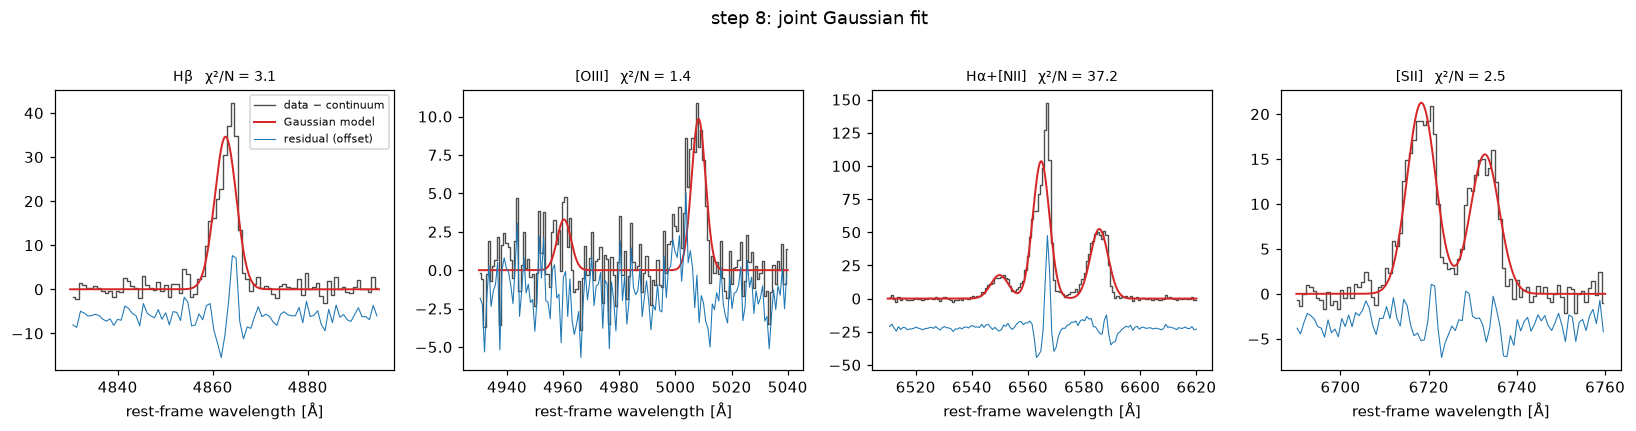

              flux   err     v   sigma     snr
Hβ          196.73  4.35  3.12  130.17   45.25
[OIII]4959   20.67  1.26  3.12  140.50   16.36
[OIII]5007   61.60  3.77  3.12  140.50   16.36
[NII]6548   141.37  1.33  3.12  140.50  106.64
Hα          766.61  5.02  3.12  130.17  152.79
[NII]6584   418.46  3.92  3.12  140.50  106.64
[SII]6716   172.98  3.20  3.12  140.50   54.03
[SII]6731   126.56  2.99  3.12  140.50   42.29


In [9]:
def gauss(wave, l0, A, v, sig_kms):
    sig_tot = np.sqrt(sig_kms**2 + sigma_inst_kms(l0 * (1 + z))**2)
    lc = l0 * (1 + v / C_KMS); sl = lc * sig_tot / C_KMS
    return A * np.exp(-0.5 * ((wave - lc) / sl) ** 2), sl

BALMER = {"Hβ", "Hα"}
FITLINES = ["Hβ", "[OIII]4959", "[OIII]5007", "[NII]6548", "Hα", "[NII]6584", "[SII]6716", "[SII]6731"]
TIES = {"[OIII]4959": ("[OIII]5007", 1 / 2.98), "[NII]6548": ("[NII]6584", 1 / 2.96)}
WINDOWS = {"Hβ": (4830, 4895), "[OIII]": (4930, 5040), "Hα+[NII]": (6510, 6620), "[SII]": (6690, 6760)}
FREE = [n for n in FITLINES if n not in TIES]

def line_model(wave, v, sigB, sigF, *amps):
    amp = dict(zip(FREE, amps))
    for dep, (ref, ratio) in TIES.items(): amp[dep] = amp[ref] * ratio
    return sum(gauss(wave, LINES[n], amp[n], v, sigB if n in BALMER else sigF)[0] for n in FITLINES)

def fit_lines(fline, label=""):
    sel = good & np.any([(wr > lo) & (wr < hi) for lo, hi in WINDOWS.values()], axis=0)
    p0 = [0.0, 100.0, 100.0] + [max(fline[sel].max() / 3, 1.0)] * len(FREE)
    popt, pcov = curve_fit(line_model, wr[sel], fline[sel], p0=p0, sigma=1 / np.sqrt(ivr[sel]), absolute_sigma=True,
                           bounds=([-500, 20, 20] + [0] * len(FREE), [500, 800, 800] + [np.inf] * len(FREE)))
    perr = np.sqrt(np.diag(pcov)); v, sigB, sigF = popt[:3]
    out = {}
    for k, n in enumerate(FREE):
        sg = sigB if n in BALMER else sigF; _, sl = gauss(wr, LINES[n], 1, v, sg)
        out[n] = dict(flux=popt[3 + k] * np.sqrt(2 * np.pi) * sl, err=perr[3 + k] * np.sqrt(2 * np.pi) * sl, v=v, sigma=sg)
        for dep, (ref, ratio) in TIES.items():
            if ref == n: out[dep] = dict(flux=out[n]["flux"] * ratio, err=out[n]["err"] * ratio, v=v, sigma=sg)
    res = pd.DataFrame(out).T.loc[FITLINES]; res["snr"] = res.flux / res.err
    chi2 = np.sum((fline[sel] - line_model(wr[sel], *popt)) ** 2 * ivr[sel]) / (sel.sum() - len(popt))
    print(f"{label}v = {v:+.0f} ± {perr[0]:.0f} km/s   σ_Balmer = {sigB:.0f} ± {perr[1]:.0f}   σ_forbidden = {sigF:.0f} ± {perr[2]:.0f} km/s   χ²ν = {chi2:.2f}")
    return res, popt

res, popt = fit_lines(fline, "joint fit: ")
fig, axs = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, (cname, (lo, hi)) in zip(axs, WINDOWS.items()):
    s = (wr > lo) & (wr < hi) & good
    ax.plot(wr[s], fline[s], color="0.3", lw=0.9, drawstyle="steps-mid", label="data − continuum")
    ww = np.linspace(lo, hi, 600); ax.plot(ww, line_model(ww, *popt), color="tab:red", lw=1.3, label="Gaussian model")
    ax.plot(wr[s], fline[s] - line_model(wr[s], *popt) - 0.15 * fline[s].max(), color="tab:blue", lw=0.7, label="residual (offset)")
    chi2c = np.sum((fline[s] - line_model(wr[s], *popt)) ** 2 * ivr[s]) / s.sum()
    ax.set_title(f"{cname}   χ²/N = {chi2c:.1f}", fontsize=9); ax.set_xlabel("rest-frame wavelength [Å]")
axs[0].legend(fontsize=7); plt.suptitle("step 8: joint Gaussian fit", y=1.02); plt.tight_layout(); plt.show()
print(res.round(2))

## Step 9 — compare with FastSpecFit

Same spectrum, same templates, a simpler procedure. Differences of ~5–10 % are expected: FastSpecFit
fits all lines and the continuum together, uses the full DESI resolution matrix, and includes the
photometry. Differences of factors are a bug — on one side or the other.

In [10]:
fs = fitsio.read(ROOT / "output/fastspecfit" / f"fastspec-{SYSTEM}.fits", "FASTSPEC")[0]
FSF = {"Hβ": "HBETA", "[OIII]4959": "OIII_4959", "[OIII]5007": "OIII_5007", "[NII]6548": "NII_6548", "Hα": "HALPHA", "[NII]6584": "NII_6584", "[SII]6716": "SII_6716", "[SII]6731": "SII_6731"}
cmp = pd.DataFrame({"by hand": res.flux, "± ": res.err, "FastSpecFit": [float(fs[f"{c}_FLUX"]) for c in FSF.values()],
                    "±": [1 / np.sqrt(float(fs[f"{c}_FLUX_IVAR"])) if fs[f"{c}_FLUX_IVAR"] > 0 else np.nan for c in FSF.values()]}, index=list(FSF))
cmp["ratio"] = cmp["by hand"] / cmp["FastSpecFit"]
print(cmp.round(3))
print(f"\nvelocity dispersion: by hand {vbest} km/s (coarse grid), FastSpecFit {fitsio.read(ROOT / 'output/fastspecfit' / f'fastspec-{SYSTEM}.fits', 'SPECPHOT')[0]['VDISP']:.0f} km/s")

            by hand     ±   FastSpecFit      ±  ratio
Hβ          196.727  4.348      189.062  4.573  1.041
[OIII]4959   20.670  1.264       20.613  1.215  1.003
[OIII]5007   61.596  3.766       61.692  3.637  0.998
[NII]6548   141.373  1.326      138.961  1.256  1.017
Hα          766.612  5.017      728.853  5.085  1.052
[NII]6584   418.464  3.924      423.691  3.828  0.988
[SII]6716   172.976  3.201      173.593  2.752  0.996
[SII]6731   126.560  2.993      131.059  3.432  0.966

velocity dispersion: by hand 60 km/s (coarse grid), FastSpecFit 162 km/s


## Step 10 — the BPT point, with and without the continuum step

The same joint Gaussian fit, but on a **naive** line spectrum: a straight line fitted to the
continuum on either side of each complex, no stellar absorption correction. Everything else is
identical, so the difference between the two points is purely the continuum step. Hβ is the line
that changes: its emission fills a deep absorption trough, and the naive continuum sits on the
wrong side of it.

naive continuum: v = +4 ± 1 km/s   σ_Balmer = 127 ± 1   σ_forbidden = 138 ± 1 km/s   χ²ν = 13.40
            template continuum  naive continuum  FastSpecFit
Hβ                       196.7            149.5        189.1
[OIII]5007                61.6             52.1         61.7
Hα                       766.6            727.2        728.9
[NII]6584                418.5            411.2        423.7


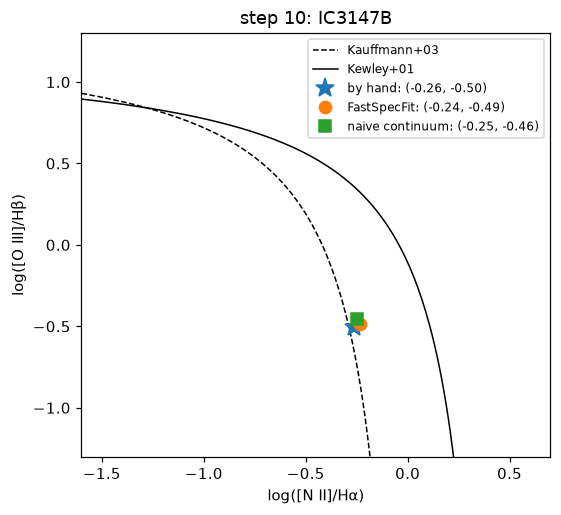

In [11]:
def kauffmann03(x): return 0.61 / (x - 0.05) + 1.3
def kewley01(x): return 0.61 / (x - 0.47) + 1.19
def ratios(F):
    return np.log10(F["[NII]6584"] / F["Hα"]), np.log10(F["[OIII]5007"] / F["Hβ"])

fline_naive = fline.copy()
for lo, hi in WINDOWS.values():
    s = (wr > lo - 40) & (wr < hi + 40) & good; side = s & mask & ((wr < lo) | (wr > hi))
    p = np.polyfit(wr[side], fr[side], 1); fline_naive[s] = (fr - np.polyval(p, wr))[s]
res_naive, _ = fit_lines(fline_naive, "naive continuum: ")
fsf_flux = {k: float(fs[f"{v}_FLUX"]) for k, v in FSF.items()}
print(pd.DataFrame({"template continuum": res.flux, "naive continuum": res_naive.flux, "FastSpecFit": pd.Series(fsf_flux)}).loc[["Hβ", "[OIII]5007", "Hα", "[NII]6584"]].round(1))
pts = {"by hand": ratios(res.flux), "FastSpecFit": ratios(fsf_flux), "naive continuum": ratios(res_naive.flux)}
fig, ax = plt.subplots(figsize=(5.5, 5))
xx = np.linspace(-1.6, 0.0, 200); ax.plot(xx[xx < 0.05], kauffmann03(xx[xx < 0.05]), "k--", lw=1, label="Kauffmann+03")
xx = np.linspace(-1.6, 0.4, 200); ax.plot(xx, kewley01(xx), "k-", lw=1, label="Kewley+01")
for (n, (x, y)), mk in zip(pts.items(), ["*", "o", "s"]):
    ax.plot(x, y, mk, ms=13 if mk == "*" else 8, label=f"{n}: ({x:+.2f}, {y:+.2f})")
ax.set(xlim=(-1.6, 0.7), ylim=(-1.3, 1.3), xlabel="log([N II]/Hα)", ylabel="log([O III]/Hβ)", title=f"step 10: {SYSTEM}"); ax.legend(fontsize=8); plt.show()

## What FastSpecFit adds on top of this

* the DESI **resolution matrix** per pixel instead of one $\sigma_{\rm inst}$ per arm;
* a finer $(\sigma_\star, A_V)$ scan, a proper attenuation law with a 2175 Å bump option, and the
  **broadband photometry** (grz + WISE) to constrain the stellar mass and the aperture correction;
* all emission lines fitted **simultaneously** with the continuum, with narrow, broad and UV
  kinematic groups, and 50 Monte-Carlo realisations for the uncertainties;
* physical outputs: stellar mass, age, SFR, $D_n(4000)$, equivalent widths, K-corrections.

Exercises: (a) change the mask half-width and watch the Hβ flux; (b) fit Hα with a second, broad Gaussian
— does χ² improve? (c) repeat on a companion spectrum; (d) push the [S II] doublet ratio to an electron
density.